# Chapter 1 - FODO Cells

## Goals

This chapter introduces the basic SciBmad workflow by constructing and analyzing a forward arc FODO cell.

By the end of the chapter, we will:

1. build a **forward arc FODO cell** from SciBmad element objects;
2. combine the elements into a `Beamline` with a reference species and energy;
3. calculate the periodic linear optics with `twiss`;
4. inspect the phase advance, beta functions, and dispersion; and
5. tune the two quadrupole strengths so that the phase advance per cell is $90^\circ$ in both planes.

The design workflow used throughout this tutorial is

$$
\text{geometry}
\longrightarrow \text{initial optics}
\longrightarrow \text{targets and variables}
\longrightarrow \text{optimization}
\longrightarrow \text{verification}.
$$

The first half of the chapter concentrates on how a lattice and its optics are represented in SciBmad. The optimization workflow is introduced afterward.


In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [1]:
# Load the accelerator-modeling, plotting, and optimization packages.
using SciBmad
using Beamlines
using CairoMakie
using LaTeXStrings
using Optim
using DifferentiationInterface
import DifferentiationInterface as DI
using GTPSA

# Use LaTeX-style fonts in all CairoMakie figures created below.
set_theme!(theme_latexfonts())


### SciBmad workflow in this chapter

The original tutorial describes the lattice with a Bmad lattice file and analyzes it interactively with Tao. Here we construct the same cell directly in Julia using SciBmad.

The main SciBmad objects used below are:

- `Quadrupole`, `Drift`, and `SBend`, which represent individual lattice elements;
- `Beamline`, which stores the elements in traversal order together with the reference particle information; and
- `twiss`, which calculates the periodic optics of the cell.

SciBmad reports the two normal-mode optics as mode 1 and mode 2. For the uncoupled lattice used here, mode 1 corresponds to the horizontal plane and mode 2 corresponds to the vertical plane.


## 1.1 Example: forward arc FODO cell

The phase advance per FODO cell is chosen to be $90^\circ$ to achieve the emittance requirements. We first construct the forward arc FODO cell without sextupoles. The sextupoles and corrector coils will be added later in the tutorial, and construction of the reverse arc FODO cell is left as an exercise.

The forward cell has the ordered element sequence

$$
\mathrm{QF} \to D1 \to B \to D2 \to \mathrm{QD} \to D1 \to B \to D2.
$$

The element lengths are:

- quadrupole length: $0.5\ \mathrm{m}$
- drift lengths: $D1 = 0.609\ \mathrm{m}$ and $D2 = 1.241\ \mathrm{m}$
- bend chord length: $L_{\mathrm{chord}} = 6.86\ \mathrm{m}$
- bend angle per dipole: $\theta_B = \pi/132$

The ESR uses rectangular bends (`rbend`) in the arcs. Following the MAD convention, the input length of an `rbend` specifies its chord length, whereas the length of an `SBend` specifies the true arc length. Since this notebook constructs an `SBend` directly, the chord length is converted using

$$
L_{\mathrm{arc}} = L_{\mathrm{chord}}
\frac{\theta_B}{2\sin(\theta_B/2)}.
$$

The collider ring has 132 arc FODO cells and two bends per cell, so each bend advances the reference orbit by $2\pi/(2\times132)=\pi/132$. We begin with arbitrary quadrupole strengths $K_1(QF)=0.4$ and $K_1(QD)=-0.4$; these values will be adjusted later.


In [4]:
# Start from the arbitrary quadrupole strengths used in the original example.
# Kn1 is SciBmad's normalized normal-quadrupole strength K1.
kqf0 = 0.4
kqd0 = -0.4

# Store the element geometry separately so it can be read and changed easily.
Lq = 0.5
Ld1 = 0.609
Ld2 = 1.241
Lchord = 6.86
theta_b = π / 132

# SBend expects its longitudinal length L to be the true arc length.
# Convert the rbend chord length used in the original tutorial before constructing it.
Lb = Lchord * theta_b / (2sin(theta_b / 2))

# Construct one SciBmad object for each distinct element in the cell.
# L sets the element length; Kn1 sets K1; angle sets the total bend angle.
qf = Quadrupole(L=Lq, Kn1=kqf0)
d1 = Drift(L=Ld1)
b  = SBend(L=Lb, angle=theta_b)
d2 = Drift(L=Ld2)
qd = Quadrupole(L=Lq, Kn1=kqd0)

# Beamline arranges the elements in traversal order.
# Reusing d1, b, and d2 inserts the same element definitions at both locations.
# species_ref and E_ref define the reference electron beam used by optics calculations.
fodo0 = Beamline(
    [qf, d1, b, d2, qd, d1, b, d2],
    species_ref=Species("electron"),
    E_ref=18e9,
)

Beamline:
 species_ref = electron
 E_ref = 1.8e10

  Index   Name   Kind         s [m]   
  1              Quadrupole   0
  2              Drift        0.5
  3              SBend        1.109
  4              Drift        7.96916
  5              Quadrupole   9.21016
  6              Drift        9.71016
  7              SBend        10.3192
  8              Drift        17.1793


## 1.2 Inspect the initial optics

We now ask SciBmad for the **periodic optics** of the one-cell beamline. The helper function `build_fodo_cell(kqf, kqd)` creates a new beamline for any chosen pair of quadrupole strengths. This allows the same cell definition to be reused during optimization.

`twiss` returns an optics table evaluated along the beamline. At the end of the table, `phi_1` and `phi_2` are the accumulated mode tunes in units of turns. Depending on the SciBmad version, these entries may be ordinary scalars or GTPSA values; `tps_const` extracts the scalar constant term used by the optimizer. Multiplying the tunes by $2\pi$ converts them to phase advances in radians:

$$
\mu_x = 2\pi\,\phi_1(\mathrm{end}),
\qquad
\mu_y = 2\pi\,\phi_2(\mathrm{end}).
$$

The wrapper `optics_table` keeps the notebook compatible with SciBmad versions that return the table directly and versions that return a Twiss object containing the table. The helper `linear_dispersion` similarly supports both explicit `eta_1`/`eta_2` columns and newer coasting-beam tables, where dispersion is stored as the momentum-offset coefficient of `orbit_x` and `orbit_y`. We first check the optics produced by the arbitrary initial strengths.


In [5]:
#To make quadrupole strengths GTPSA variables, write the GTPSA descriptor with two parameters    
d=Descriptor(6,2,2,1)
deltap=params(d)

2-element Vector{TPS64{GTPSA.Dynamic}}:
Descriptor(NV=6, MO=2, NP=2, PO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
---------------------------------------------------------
  1:  1.0000000000000000E+000    1     0 0  0 0  0 0  7^1
---------------------------------------------------------
  2:  1.0000000000000000E+000    1     0 0  0 0  0 0  8^1


In [6]:
# Exponent selectors used when a value returned by SciBmad is a GTPSA object.
# zero6 selects its constant term; delta1 selects the coefficient of momentum offset.
zero6  = [0, 0, 0, 0, 0, 0]
delta1 = [0, 0, 0, 0, 0, 1]

# Return the constant part of a GTPSA value, or return an ordinary scalar unchanged.
function tps_const(x)
    try
        return x[zero6]
    catch
        return x
    end
end

# Return the coefficient linear in momentum offset when it is available.
function tps_delta_coeff(x)
    try
        return x[delta1]
    catch
        return zero(tps_const(x))
    end
end
# Build the same FODO geometry for any proposed QF and QD strengths.
# Keeping lattice construction in a function lets later analysis reuse it.
function build_fodo_cell(kqf, kqd; knobs=false)
    qf = Quadrupole(L=0.5, Kn1=kqf)
    d1 = Drift(L=0.609)
    b  = SBend(L=6.86 * (π / 132) / (2sin((π / 132) / 2)), angle=π / 132)
    d2 = Drift(L=1.241)
    qd = Quadrupole(L=0.5, Kn1=kqd)
    if knobs
        qf.Kn1 = qf.Kn1 + deltap[1]
        qd.Kn1 = qd.Kn1 + deltap[2]
    end
    return Beamline(
        [qf, d1, b, d2, qd, d1, b, d2],
        species_ref=Species("electron"),
        E_ref=18e9,
    )
end

# SciBmad 0.1 returns the optics table directly, while newer versions
# return a Twiss object containing the table. Normalize both forms here.
optics_table(tw) = hasproperty(tw, :table) ? tw.table : tw

# Run twiss for a cell built from k = [kqf, kqd].
# phi_1 and phi_2 at the final table row are the accumulated mode tunes.
function cell_tunes(k)
    tw=twiss(build_fodo_cell(k[1], k[2]; knobs=true),GTPSA_descriptor=d)
    t = optics_table(tw)
    return tps_const(t.phi_1[end]), tps_const(t.phi_2[end])
end

# SciBmad stores phi in turns, so multiply by 2π to obtain radians.
function cell_phase_advances(k)
    Qx, Qy = cell_tunes(k)
    return 2π * Qx, 2π * Qy
end

# Extract dispersion from either the older explicit eta columns or the
# momentum-offset coefficient of the closed orbit used by newer SciBmad versions.
function linear_dispersion(tw_table)
    if hasproperty(tw_table, :eta_1)
        return tw_table.eta_1, tw_table.eta_2
    end
    return tps_delta_coeff.(tw_table.orbit_x), tps_delta_coeff.(tw_table.orbit_y)
end

linear_dispersion (generic function with 1 method)

In [7]:
# Calculate the periodic Twiss solution for the initial beamline.
tw0 = twiss(fodo0)
# Extract the underlying table so its columns can be inspected directly.
t0 = optics_table(tw0)

# Evaluate the end-of-cell phase advances for the initial strengths.
μx0, μy0 = cell_phase_advances([kqf0, kqd0])

println("Initial phase advances:")
println("  μx = ", μx0, " rad = ", μx0 * 180 / π, " deg")
println("  μy = ", μy0, " rad = ", μy0 * 180 / π, " deg")
println()
println("Target phase advance:")
println("  π/2 rad = 90 deg")

Initial phase advances:
  μx = 2.260095493758938 rad = 129.49393308892303 deg
  μy = 2.2587613619459845 rad = 129.41749296672668 deg

Target phase advance:
  π/2 rad = 90 deg


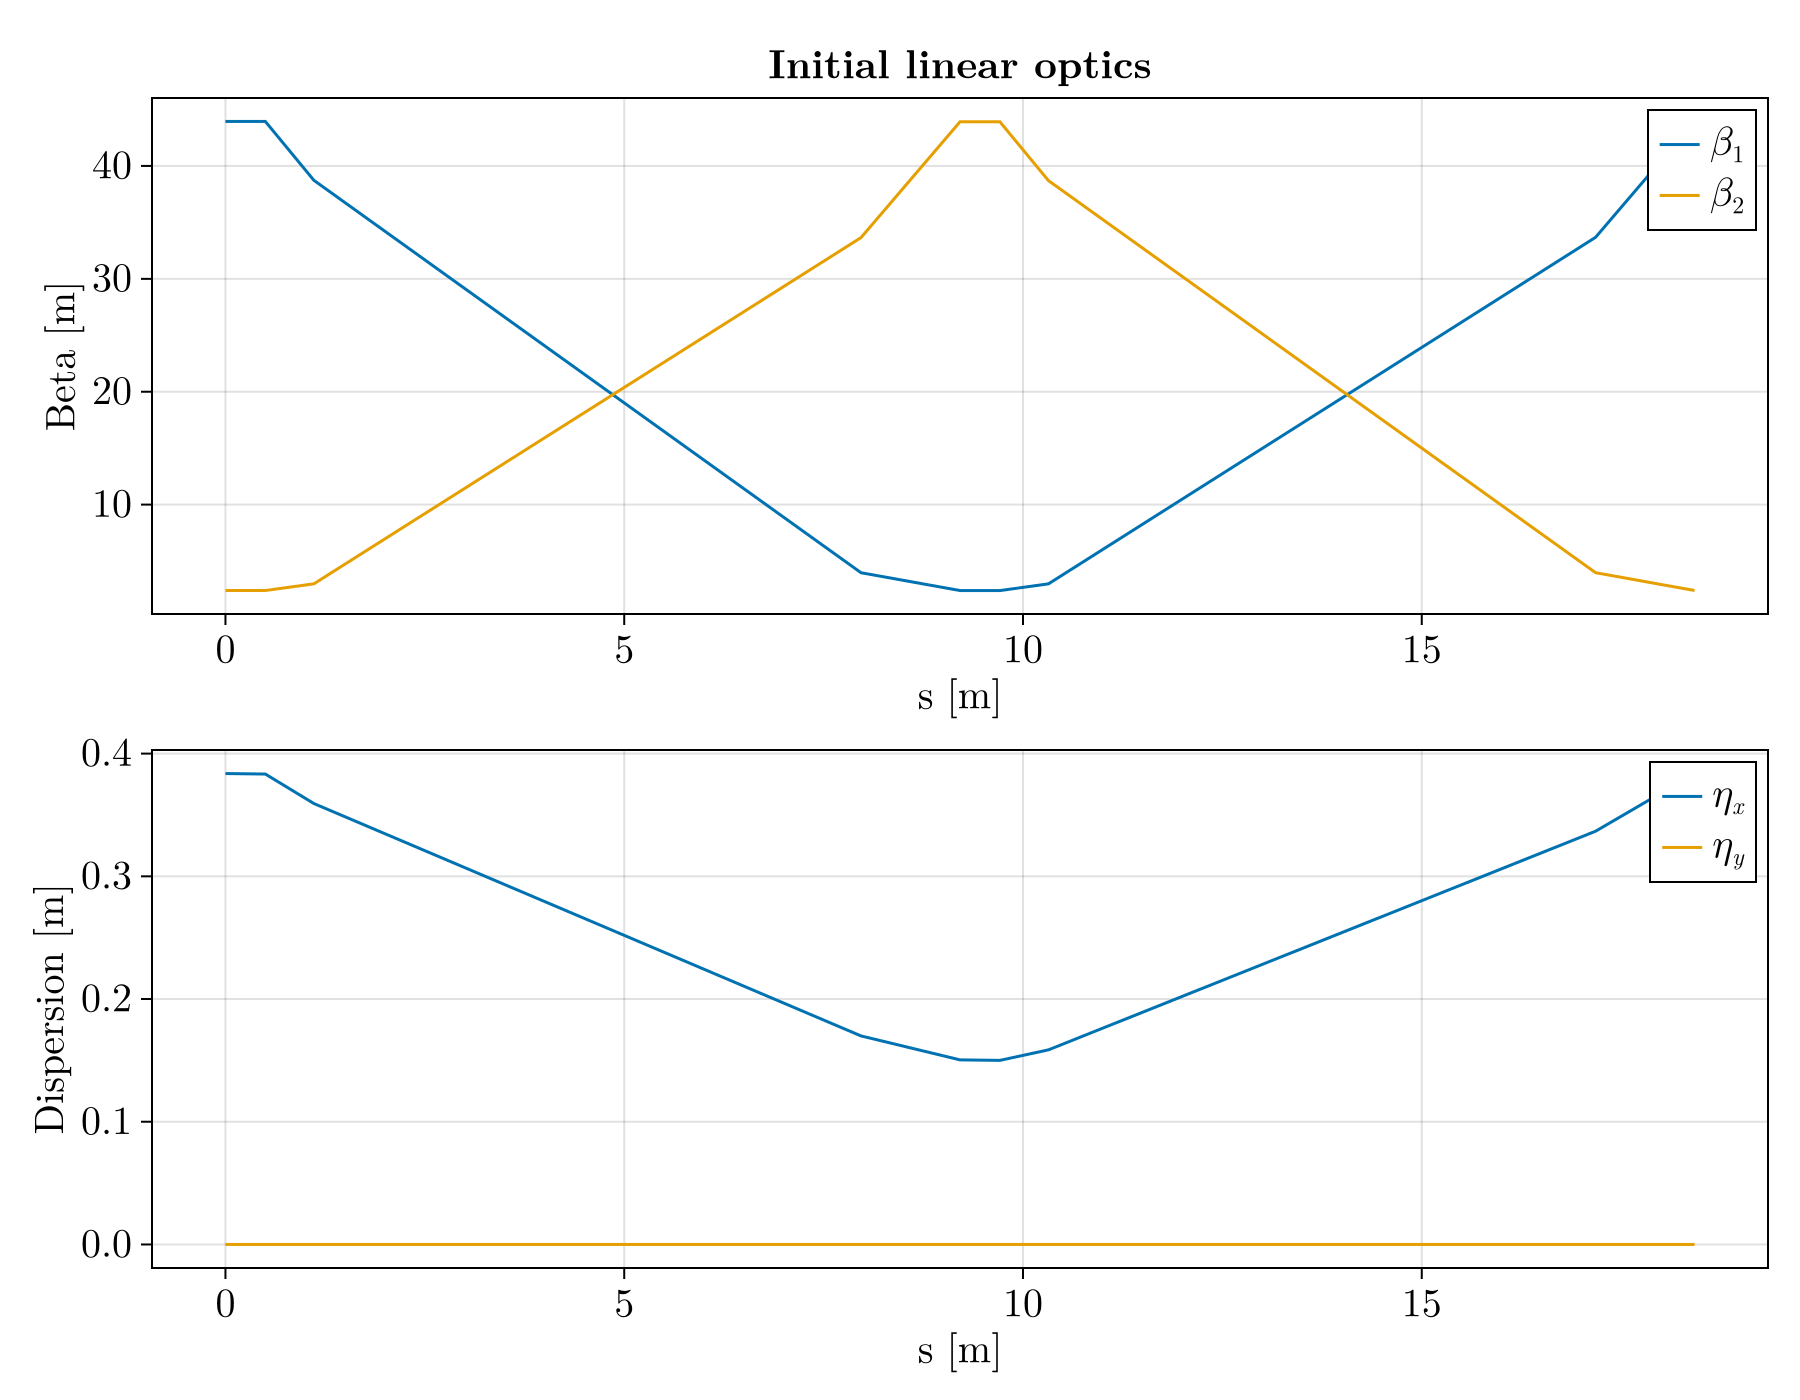

In [8]:
# Accept a SciBmad Twiss result and return a CairoMakie Figure.
function plot_linear_optics(tw; title_text="Initial linear optics")
    # Read the optics table and its two dispersion columns.
    t = optics_table(tw)
    ηx, ηy = linear_dispersion(t)

    # Create a figure with one axis for beta functions and one for dispersion.
    f = Figure(fontsize=20, size=(900, 700))

    # SciBmad table columns beta_1 and beta_2 contain the normal-mode beta functions.
    ax1 = Axis(f[1, 1], xlabel="s [m]", ylabel="Beta [m]", title=title_text)
    lines!(ax1, t.s, t.beta_1, label=L"\beta_1")
    lines!(ax1, t.s, t.beta_2, label=L"\beta_2")
    axislegend(ax1, position=:rt)

    # Plot the dispersion columns against the same longitudinal coordinate t.s.
    ax2 = Axis(f[2, 1], xlabel="s [m]", ylabel="Dispersion [m]")
    lines!(ax2, t.s, ηx, label=L"\eta_x")
    lines!(ax2, t.s, ηy, label=L"\eta_y")
    axislegend(ax2, position=:rt)

    return f
end

# Display the initial periodic optics.
plot_linear_optics(tw0)

### Inspecting the SciBmad optics table

The plotting function below reads the longitudinal locations from `t.s`, the two normal-mode beta functions from `t.beta_1` and `t.beta_2`, and version-compatible dispersion arrays returned by `linear_dispersion`. For this uncoupled lattice, the mode-1 and mode-2 beta functions correspond to the horizontal and vertical beta functions.

The purpose of this first plot is to inspect the initial cell before changing any strengths. After optimization, the same table fields will be used to compare the initial and final optics.


## 1.3 Build the merit function

An optimizer needs a numerical statement of the design problem. The original Tao workflow separates this statement into two main categories:

- **data** are quantities that the lattice should reproduce, such as a target phase advance;
- **variables** are adjustable machine parameters, such as quadrupole strengths.

In the original Chapter 1, the two data are called `phase.a` and `phase.b`, evaluated at the end of the FODO cell. For an uncoupled lattice, they correspond to $\mu_x$ and $\mu_y$. The two variables are the `K1` attributes of `QF` and `QD`.

In this Julia translation, we do not need to reproduce Tao's hierarchical data structures explicitly. The same information is represented compactly by

$$
\mathbf{k} = \begin{pmatrix}k_{QF} & k_{QD}\end{pmatrix},
\qquad
\mathbf{r}(\mathbf{k}) =
\begin{pmatrix}
\mu_x(\mathbf{k})-\pi/2 \\
\mu_y(\mathbf{k})-\pi/2
\end{pmatrix}.
$$

We turn these residuals into a scalar **merit function**.  
Optimization is formulated by minimizing a merit function of the form

$$
\mathcal{M} \equiv \sum_i w_i \,[\delta D_i]^2 + \sum_j w_j \,[\delta V_j]^2,
$$

where the first sum runs over the data and the second sum represents optional penalties on the variables. The quantities $\delta D_i$ measure how far the current lattice is from the desired optics targets. A variable penalty can be useful when many nearly equivalent solutions exist or when excessively large magnet strengths should be discouraged. This two-variable example does not require such a penalty.

For the present one-cell FODO example, the design goal is simple: at the **end of the cell**, the horizontal and vertical phase advances should both be $90^\circ$. In other words, we want

$$
\mu_x = \frac{\pi}{2}, \qquad \mu_y = \frac{\pi}{2}.
$$

A natural version of the merit function is therefore

$$
M(k_{QF}, k_{QD})
=
w_x \left(\mu_x - \frac{\pi}{2}\right)^2
+
w_y \left(\mu_y - \frac{\pi}{2}\right)^2,
$$

where $\mu_x$ and $\mu_y$ are recalculated from the periodic one-cell optics every time $k_{QF}$ or $k_{QD}$ changes.

We choose the optimization targets

- `phase.a = π/2`
- `phase.b = π/2`

and assign both targets the same weight,

$$
w_x = w_y = 1.
$$

Weights set the relative importance and numerical scale of different residuals. Since the two phase targets have the same units and equal importance, we give them equal weights. With this choice, the merit function becomes

$$
M(k_{QF}, k_{QD})
=
 \left(\mu_x - \frac{\pi}{2}\right)^2
+
 \left(\mu_y - \frac{\pi}{2}\right)^2.
$$

A perfect match has $M=0$. More generally, a decreasing value of $M$ means that the proposed lattice is moving closer to the requested optics.

In [9]:
# Step 1: Define the desired phase advance and the weight of each target.
mu_target = π / 2
weight_x = 1
weight_y = 1

# Step 2: Convert a proposed strength vector k = [kqf, kqd] into one scalar merit.
# cell_phase_advances rebuilds the cell and calculates its periodic optics.
function merit(k)
    μx, μy = cell_phase_advances(k)
    # Add the weighted squared errors of the two phase-advance targets.
    return sum(abs2,[μx-pi/2, μy-pi/2])
end

# Evaluate the objective once at the starting quadrupole strengths.
println("Initial merit = ", merit([kqf0, kqd0]))

Initial merit = 0.9484292311677591


## 1.4 Differentiate the objective

Gradient-based optimization uses not only the merit value $M$, but also its local sensitivity to each variable:

$$
\nabla M =
\begin{pmatrix}
\partial M/\partial k_{QF} \\
\partial M/\partial k_{QD}
\end{pmatrix}.
$$

The gradient tells the optimizer which combination of quadrupole changes most rapidly reduces the optics error.

### 1.4.1 Finite Difference

The most transparent way to obtain the gradient is a centered finite difference, which we use here as a baseline before the map-based method that SciBmad makes available (Section 1.4.2):

$$
\frac{\partial M}{\partial k_i}
\approx
\frac{M(\mathbf{k}+h_i\mathbf{e}_i)-M(\mathbf{k}-h_i\mathbf{e}_i)}{2h_i}.
$$

The code perturbs one quadrupole strength at a time, rebuilds the cell, recomputes the periodic Twiss solution, and measures the change in merit. Centered differences require two evaluations per variable but are more accurate than one-sided differences for the same step size. The problem has only two variables, so this extra cost is small. Its accuracy still depends on the step size $h_i$; the GTPSA method below avoids that tradeoff by evaluating the derivatives exactly.

In [10]:
# Store the two initial optimization variables in the order [QF.Kn1, QD.Kn1].
k0 = [kqf0, kqd0]
g0 = zeros(length(k0))

2-element Vector{Float64}:
 0.0
 0.0

In [11]:
# Fill storage with the gradient of merit at k using centered finite differences.
function merit_gradient!(storage, k)
    # Perturb one quadrupole strength at a time.
    for i in eachindex(k)
        # Scale the finite-difference step to the magnitude of the current variable.
        h = cbrt(eps(Float64)) * max(abs(k[i]), 1.0)
        # kp and km hold the positive and negative perturbations of k.
        kp = copy(k)
        km = copy(k)
        kp[i] += h
        km[i] -= h
        # Each merit call rebuilds the lattice and recalculates the periodic optics.
        storage[i] = (merit(kp) - merit(km)) / (2h)
    end
    return storage
end

# Allocate gradient storage and inspect the gradient at the initial point.
merit_gradient!(g0, k0)

println("Gradient of the merit at the initial point:")
println(g0)

Gradient of the merit at the initial point:
[14.598362890574224, -14.557942185894163]


### 1.4.2 GTPSA Method for calculating Gradient

The finite-difference method above differentiates the scalar merit directly, but its accuracy is limited by the choice of step size. The approach we recommend is to use GTPSA: because SciBmad already builds the one-turn map as a truncated power series, the exact local Jacobian of the two phase advances with respect to the two quadrupole strengths is available directly, with no step-size tuning. We then apply the chain rule.

Define the residual vector

$$
\mathbf{r}(\mathbf{k}) =
\begin{pmatrix}
\mu_x(\mathbf{k}) - \pi/2 \\
\mu_y(\mathbf{k}) - \pi/2
\end{pmatrix},
\qquad
\mathbf{k} =
\begin{pmatrix}
k_{QF} \\
k_{QD}
\end{pmatrix}.
$$

For the merit with same weights, it can be written as

$$
M(\mathbf{k}) = \mathbf{r}(\mathbf{k})^T\mathbf{r}(\mathbf{k}),
$$

so the chain rule gives

$$
\nabla_{\mathbf{k}}M
=
2\left(\frac{\partial\mathbf{r}}{\partial\mathbf{k}}\right)^T
\mathbf{r}.
$$

Because the target constants have zero derivative, $\partial\mathbf{r}/\partial\mathbf{k}$ is just the phase-advance Jacobian

$$
\frac{\partial\mathbf{r}}{\partial\mathbf{k}}
=
\begin{pmatrix}
\partial\mu_x/\partial k_{QF} & \partial\mu_x/\partial k_{QD} \\
\partial\mu_y/\partial k_{QF} & \partial\mu_y/\partial k_{QD}
\end{pmatrix}.
$$

SciBmad's `tunes` are in turns, while the residual uses phase advance in radians. Therefore the GTPSA derivative of the tune must be multiplied by $2\pi$ before it is used in the chain rule.

In [12]:
function Jacobian(k)
    return 2pi .* vcat(GTPSA.gradient(par(twiss(build_fodo_cell(k[1], k[2]; knobs=true),GTPSA_descriptor=d).tunes[1], [0,0,0,0,0,0,:]), include_params=true)[7:end]',GTPSA.gradient(par(twiss(build_fodo_cell(k[1], k[2]; knobs=true),GTPSA_descriptor=d).tunes[2], [0,0,0,0,0,0,:]), include_params=true)[7:end]')
end

function gradient1(storage,k)
    μx, μy = cell_phase_advances(k)
    storage.=2*Jacobian(k)'*[μx-pi/2, μy-pi/2]
    return storage
end

gradient1 (generic function with 1 method)

## 1.5 Optimize the quadrupole strengths

We now pass the objective to `Optim.jl`. We first let the optimizer work from the merit function alone, and then compare that result with two versions where we supply the gradient explicitly. The optimization vector is

$$
\mathbf{k}=\begin{pmatrix}k_{QF} & k_{QD}\end{pmatrix}.
$$

`LBFGS` is a local, gradient-based algorithm that builds an approximation to the curvature of the merit function from successive gradients. `Fminbox` adds lower and upper bounds. Here the bounds preserve the intended focusing signs and keep the search within a linearly stable neighborhood:

$$
0.2 \le k_{QF} \le 0.6,
\qquad
-0.6 \le k_{QD} \le -0.2.
$$

At every iteration, the optimizer proposes a new pair of strengths, `merit` rebuilds the FODO cell and calls `twiss`, and the trace reports whether the scalar mismatch is decreasing. Convergence of the algorithm is useful evidence, but the final optics must still be checked directly.


### 1.5.1 Optimization with Merit Function Only

The simplest way to call the optimizer is to provide only the scalar merit function. In this case, `Optim.jl` evaluates `merit(k)` at proposed quadrupole strengths and estimates any derivative information it needs internally. This is the closest analogue to saying: here is the number we want to minimize, now search for a better pair of quadrupole strengths.

This form is useful pedagogically because it separates the optimization problem from the derivative calculation. The following sections then make the derivative step explicit, first with finite differences and then with GTPSA.


In [13]:
# Keep the search inside the linearly stable FODO region.
lower = [0.2, -0.6]
upper = [0.6, -0.2]

# Minimize merit starting from k0 without supplying an explicit gradient.
result_merit_only = optimize(
    merit,
    lower,
    upper,
    copy(k0),
    Fminbox(LBFGS()),
    Optim.Options(
        iterations=200,
        show_trace=true,
        show_every=1,
    ),
)

kopt_merit_only = Optim.minimizer(result_merit_only)

println()
println("Optimization converged? ", Optim.converged(result_merit_only))
println("Optimized strengths from merit-only optimization:")
println("  KQF = ", kopt_merit_only[1])
println("  KQD = ", kopt_merit_only[2])
println("Final merit = ", Optim.minimum(result_merit_only))


Fminbox
-------
Initial mu = 0.0

Fminbox iteration 1
-------------------
Calling inner optimizer with mu = 0.0

(numbers below include barrier contribution)
Iter     Function value   Gradient norm 
     0     9.578143e-01     1.459836e+01
 * time: 0.021000146865844727
     1     1.799964e-01     3.315798e+00
 * time: 2.1100001335144043
     2     7.766853e-02     3.947784e+00
 * time: 2.128000020980835
     3     1.169554e-02     6.389486e-01
 * time: 2.1449999809265137
     4     1.004428e-02     8.171540e-02
 * time: 2.1619999408721924
     5     1.000019e-02     6.206156e-04
 * time: 2.17900013923645
     6     1.000019e-02     4.225201e-06
 * time: 2.196000099182129
     7     1.000019e-02     2.944302e-08
 * time: 2.2139999866485596
     8     1.000019e-02     2.018342e-10
 * time: 2.2320001125335693

Exiting inner optimizer with x = [0.31275518436913646, -0.3128888266815405]
Current distance to box: 0.112755
Decreasing barrier term μ.

Fminbox iteration 2
-------------------
Cal

### 1.5.2 Optimizing with Finite-Difference Gradient

In [14]:
# Give Optim.jl the in-place gradient function defined above.
g! = merit_gradient!

# Keep the search inside the linearly stable FODO region.
lower = [0.2, -0.6]
upper = [0.6, -0.2]

# Minimize merit starting from k0 while enforcing the lower and upper bounds.
result = optimize(
    merit,
    g!,
    lower,
    upper,
    # Pass a copy so the original starting vector k0 is left unchanged.
    copy(k0),
    # Fminbox handles the bounds; LBFGS performs the inner gradient-based search.
    Fminbox(LBFGS()),
    Optim.Options(
        # Print the merit trace so the progress of the optimization is visible.
        iterations=200,
        show_trace=true,
        show_every=1,
    ),
)

# Extract the optimized vector [QF.Kn1, QD.Kn1] from the result object.
kopt = Optim.minimizer(result)

println()
println("Optimization converged? ", Optim.converged(result))
println("Optimized strengths:")
println("  KQF = ", kopt[1])
println("  KQD = ", kopt[2])
println("Final merit = ", Optim.minimum(result))

Fminbox
-------
Initial mu = 0.0

Fminbox iteration 1
-------------------
Calling inner optimizer with mu = 0.0

(numbers below include barrier contribution)
Iter     Function value   Gradient norm 
     0     9.578143e-01     1.459836e+01
 * time: 0.0
     1     1.799964e-01     3.315798e+00
 * time: 0.03600001335144043
     2     7.766853e-02     3.947784e+00
 * time: 0.05299997329711914
     3     1.169554e-02     6.389486e-01
 * time: 0.0709998607635498
     4     1.004428e-02     8.171540e-02
 * time: 0.08699989318847656
     5     1.000019e-02     6.206156e-04
 * time: 0.10699987411499023
     6     1.000019e-02     4.225201e-06
 * time: 0.23599982261657715
     7     1.000019e-02     2.944302e-08
 * time: 0.25099992752075195
     8     1.000019e-02     2.018342e-10
 * time: 0.2649998664855957

Exiting inner optimizer with x = [0.31275518436913646, -0.3128888266815405]
Current distance to box: 0.112755
Decreasing barrier term μ.

Fminbox iteration 2
-------------------
Calling in

### 1.5.3 Optimization with GTPSA Gradient

In [15]:
# Keep the search inside the linearly stable FODO region.
lower = [0.2, -0.6]
upper = [0.6, -0.2]

# Minimize merit starting from k0 while enforcing the lower and upper bounds.
result = optimize(
    merit,
    gradient1,
    lower,
    upper,
    # Pass a copy so the original starting vector k0 is left unchanged.
    copy(k0),
    # Fminbox handles the bounds; LBFGS performs the inner gradient-based search.
    Fminbox(LBFGS()),
    Optim.Options(
        # Print the merit trace so the progress of the optimization is visible.
        iterations=200,
        show_trace=true,
        show_every=1,
    ),
)

# Extract the optimized vector [QF.Kn1, QD.Kn1] from the result object.
kopt = Optim.minimizer(result)

println()
println("Optimization converged? ", Optim.converged(result))
println("Optimized strengths:")
println("  KQF = ", kopt[1])
println("  KQD = ", kopt[2])
println("Final merit = ", Optim.minimum(result))

Fminbox
-------
Initial mu = 0.0

Fminbox iteration 1
-------------------
Calling inner optimizer with mu = 0.0

(numbers below include barrier contribution)
Iter     Function value   Gradient norm 
     0     9.578143e-01     1.459836e+01
 * time: 0.0
     1     1.799964e-01     3.315798e+00
 * time: 0.06399989128112793
     2     7.766853e-02     3.947784e+00
 * time: 0.07500004768371582
     3     1.169554e-02     6.389487e-01
 * time: 0.08500003814697266
     4     1.004428e-02     8.171541e-02
 * time: 0.0969998836517334
     5     1.000019e-02     6.206156e-04
 * time: 0.1099998950958252
     6     1.000019e-02     4.225209e-06
 * time: 0.15899991989135742
     7     1.000019e-02     2.944244e-08
 * time: 0.16899991035461426
     8     1.000019e-02     2.019269e-10
 * time: 0.1809999942779541

Exiting inner optimizer with x = [0.31275518436664235, -0.3128888266790455]
Current distance to box: 0.112755
Decreasing barrier term μ.

Fminbox iteration 2
-------------------
Calling inn

## 1.6 Verify the optimized optics

Optimization is only the search procedure; verification establishes that the result satisfies the accelerator-physics requirements. We finish with three checks:

1. verify numerically that the phase advances are now close to $90^\circ$;
2. confirm that the final merit is close to zero and that the optimizer reports convergence;
3. compare the beta functions and dispersion before and after optimization.

The optimized beta functions should remain finite and periodic. The dispersion need not vanish in an arc cell; it should instead form a smooth periodic solution. A later dispersion suppressor will match this nonzero arc dispersion into a zero-dispersion straight section.


In [16]:
# Rebuild the FODO cell with the optimized strengths and calculate its optics.
tw_opt = twiss(build_fodo_cell(kopt[1], kopt[2]))

# Independently evaluate the final phase advances for the numerical check below.
μx_opt, μy_opt = cell_phase_advances(kopt)

println("Optimized phase advances:")
println("  μx = ", μx_opt, " rad = ", μx_opt * 180 / π, " deg")
println("  μy = ", μy_opt, " rad = ", μy_opt * 180 / π, " deg")

Optimized phase advances:
  μx = 1.5707963271220031 rad = 90.00000001874182 deg
  μy = 1.5707963268253318 rad = 90.00000000174381 deg


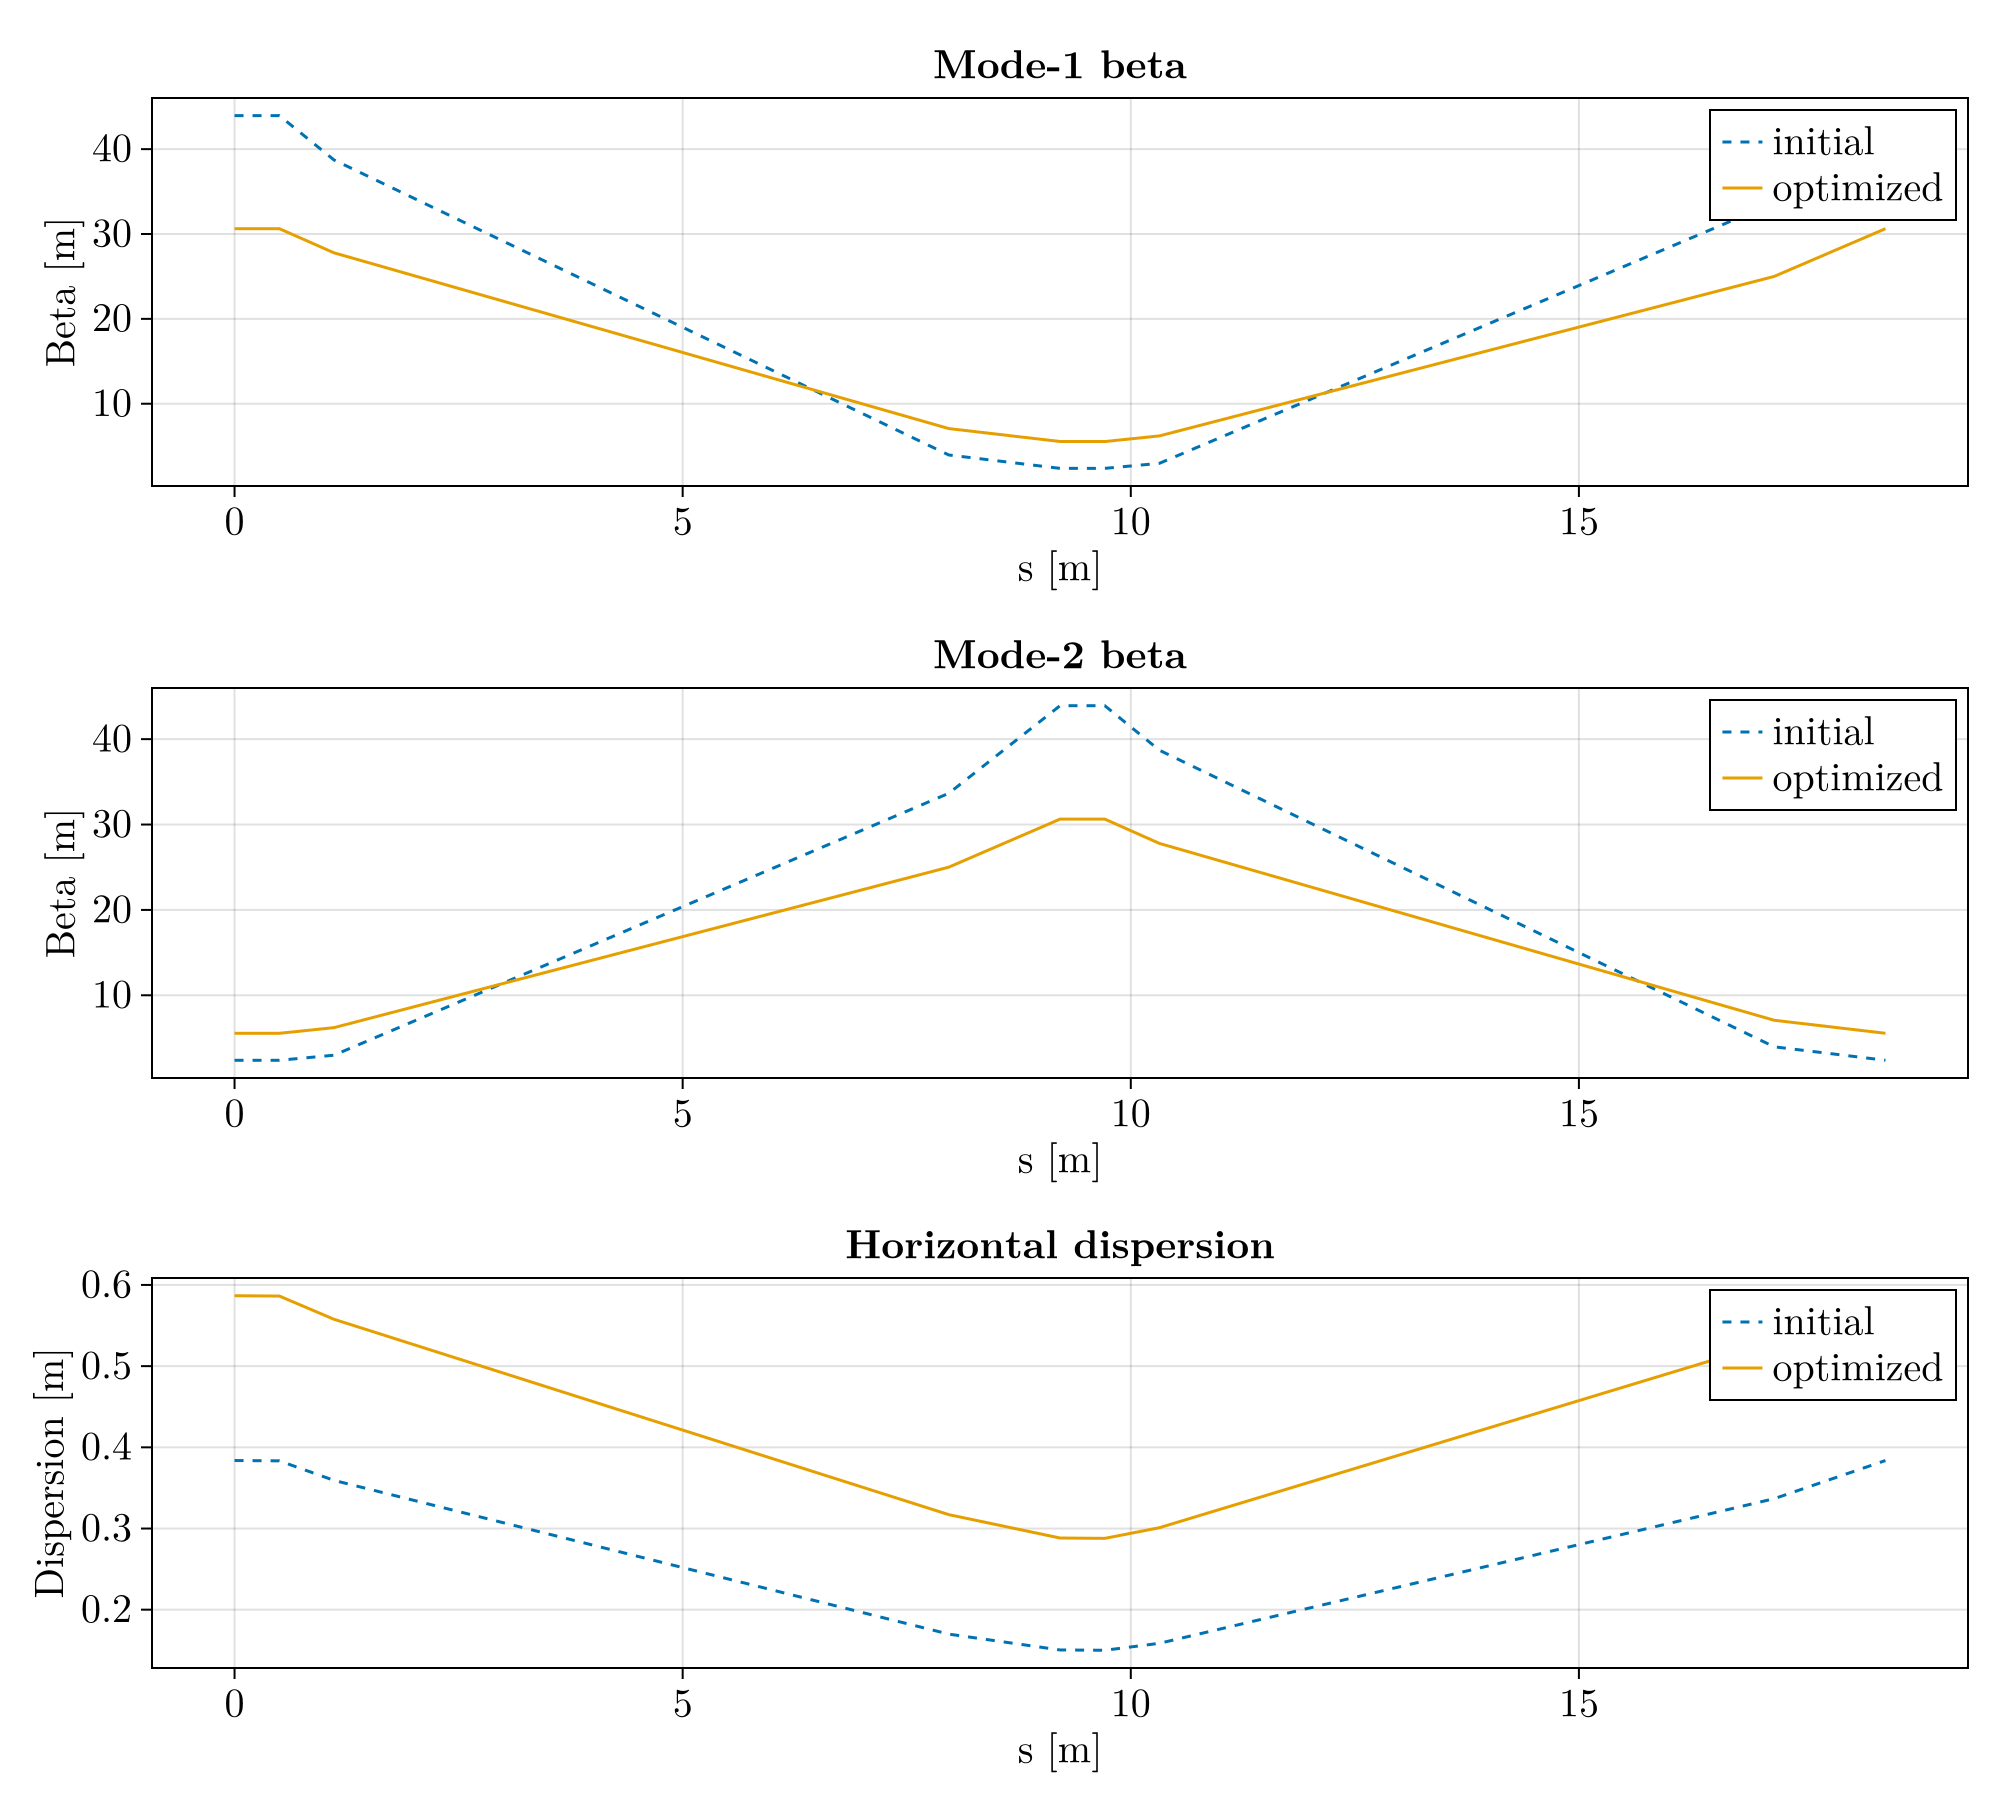

In [17]:
# Compare selected SciBmad optics-table columns before and after optimization.
function compare_optics(tw_initial, tw_final)
    # Normalize both Twiss return formats to their underlying tables.
    ti = optics_table(tw_initial)
    tf = optics_table(tw_final)

    # Extract the initial and optimized dispersion arrays.
    ηxi, ηyi = linear_dispersion(ti)
    ηxf, ηyf = linear_dispersion(tf)

    # Use dashed lines for the initial optics and solid lines for the optimized optics.
    f = Figure(fontsize=20, size=(1000, 900))

    ax1 = Axis(f[1, 1], xlabel="s [m]", ylabel="Beta [m]", title="Mode-1 beta")
    lines!(ax1, ti.s, ti.beta_1, linestyle=:dash, label="initial")
    lines!(ax1, tf.s, tf.beta_1, label="optimized")
    axislegend(ax1, position=:rt)

    ax2 = Axis(f[2, 1], xlabel="s [m]", ylabel="Beta [m]", title="Mode-2 beta")
    lines!(ax2, ti.s, ti.beta_2, linestyle=:dash, label="initial")
    lines!(ax2, tf.s, tf.beta_2, label="optimized")
    axislegend(ax2, position=:rt)

    ax3 = Axis(f[3, 1], xlabel="s [m]", ylabel="Dispersion [m]", title="Horizontal dispersion")
    lines!(ax3, ti.s, ηxi, linestyle=:dash, label="initial")
    lines!(ax3, tf.s, ηxf, label="optimized")
    axislegend(ax3, position=:rt)

    return f
end

# Display the comparison using the initial and optimized Twiss results.
compare_optics(tw0, tw_opt)

## 1.7 Export the optimized forward arc strengths

Later chapters rebuild the forward arc FODO cell before constructing the dispersion suppressor and matching sections. Save the optimized quadrupole strengths in a small Julia solution file so those chapters can load the values directly.

In [18]:
kQF_arc = kopt[1]
kQD_arc = kopt[2]

solution_text = """
# chapter1_fodoF_solution.jl
# Auto-generated by Chapter 1 notebook.

kQF_arc = $(repr(kQF_arc))
kQD_arc = $(repr(kQD_arc))
"""

solution_path = joinpath("lattices", "chapter_1", "chapter1_fodoF_solution.jl")
mkpath(dirname(solution_path))
write(solution_path, solution_text)

println("Wrote: ", solution_path)
println()
println(solution_text)

Wrote: lattices\chapter_1\chapter1_fodoF_solution.jl

# chapter1_fodoF_solution.jl
# Auto-generated by Chapter 1 notebook.

kQF_arc = 0.3126590970228428
kQD_arc = -0.3127928792873676



## 1.8 Exercises

The following exercises are adapted directly from the original Chapter 1 tutorial, but are phrased for the present SciBmad/Julia workflow.

1. **Reverse arc FODO.**  
   Construct the reverse arc FODO cell without sextupoles, and determine the quadrupole strengths that give a $90^\circ$ phase advance in both planes.

2. **Forward straight-section FODO.**  
   Replace the dipoles in the forward cell by a drift of length $5.855\ \mathrm{m}$ and rename these drifts `DB`. This length is chosen to produce the same straight-section length as in the RHIC tunnel. Rename the horizontally focusing and defocusing quadrupoles `QFSS` and `QDSS`, respectively. Which quadrupole strengths lead to a $90^\circ$ phase advance in both planes?

3. **Reverse straight-section FODO.**  
   Replace the dipoles in the reverse cell by a drift of length $5.855\ \mathrm{m}$ and rename these drifts `DB`. Rename the horizontally focusing and defocusing quadrupoles `QFSS` and `QDSS`, respectively. Which quadrupole strengths lead to a $90^\circ$ phase advance in both planes? The optimized quadrupole strengths should be exactly the same as in Exercise 2.

4. **Analytical FODO cell.**  
   Consider a FODO model with the same total length as constructed above, but with zero-length quadrupoles and no bends. Calculate by hand the quadrupole strengths that give a $90^\circ$ phase advance in both $x$ and $y$. What are the beta functions at the thin quadrupoles? How do the quadrupole strengths and beta functions compare with the numerical values found above?

5. **Forward and reverse cells.**  
   Check that the forward and reverse arc FODO cells, both starting with a focusing quadrupole, have different periodic beta and alpha functions. Check also that for the same phase advance of $90^\circ$, they have exactly the same quadrupole strengths. Explain why this is possible.

6. **Arc length and chord length.**  
   For the bend used above, calculate both $L_{\mathrm{arc}}$ and $L_{\mathrm{chord}}$. What is their numerical difference? Confirm the value using the conversion formula in Section 1.1, and explain why the difference becomes smaller as $\theta_B\to0$.

7. **Inspect the SciBmad lattice.**  
   Examine the elements in `fodo0` and make a compact table containing the element index, element type, length, quadrupole strength, and bend angle. Confirm the total cell length and identify the locations at which the periodic optics table is evaluated.

8. **Inspect individual optimization residuals.**  
   Write a function that returns the two weighted contributions

   $$
   M_x = w_x\left(\mu_x-\frac{\pi}{2}\right)^2,
   \qquad
   M_y = w_y\left(\mu_y-\frac{\pi}{2}\right)^2.
   $$

   Print $M_x$ and $M_y$ before and after optimization. Which plane dominates the initial merit, and how does this compare with the original Tao `show constraints` discussion?

9. **Enable and disable a target.**  
   Modify the merit function so that either the horizontal or vertical phase target can be switched off. Optimize with only one target active. Explain why two independently adjustable quadrupole strengths are needed to determine both phase advances uniquely.

